# Projeto de Ciência de Dados – Análise de Acidentes de Trânsito (2017–2024)

## 📌 Informações Gerais

* **Disciplina:** Ciência de Dados
* **Base de dados:** Acidentes de trânsito em rodovias federais do Brasil (DATATRAN – 2017 a 2024)
* **Metodologia:** CRISP-DM

**Objetivo:** Explorar e analisar dados de acidentes de trânsito nas rodovias federais do Brasil para obter insights valiosos sobre padrões, tendências e fatores de risco.

---

##  Importação de Bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Estatísticas
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm

# Utilitários
import os
import warnings
from datetime import datetime
import glob

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuração para exibir todas as colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


---

# 1. Business Understanding

## 🎯 Contexto do Problema

### O que é o DATATRAN?

O DATATRAN é a base oficial de dados da **Polícia Rodoviária Federal (PRF)** que registra informações sobre acidentes de trânsito ocorridos nas rodovias federais do Brasil. Esta base contém dados detalhados sobre:

- **Características dos acidentes:** tipo, causa, condições climáticas, estado da pista
- **Informações temporais:** data, hora, dia da semana
- **Localização:** estado, município, rodovia, quilômetro
- **Consequências:** número de feridos, mortos, veículos envolvidos
- **Dados das pessoas envolvidas:** idade, sexo, condição (condutor, passageiro, pedestre)

### Problemas de Negócio

1. **Impacto Social:** Acidentes de trânsito são uma das principais causas de morte no Brasil
2. **Impacto Econômico:** Custos com saúde pública, perda de produtividade, danos materiais
3. **Segurança Pública:** Necessidade de políticas preventivas eficazes

### Stakeholders

- **Governo:** Ministério da Infraestrutura, PRF, DNIT
- **Sociedade Civil:** Motoristas, pedestres, famílias das vítimas
- **Órgãos de Saúde:** SUS, hospitais, serviços de emergência
- **Seguradoras:** Análise de risco e precificação

### Perguntas de Negócio

1. Quais são os principais fatores que contribuem para acidentes graves?
2. Existe sazonalidade nos acidentes (horário, dia da semana, mês)?
3. Quais rodovias e regiões apresentam maior risco?
4. Como a pandemia (2020-2021) afetou os padrões de acidentes?
5. Qual o perfil das vítimas mais vulneráveis?

---

# 2. Data Understanding

## 📊 Carregamento e Exploração Inicial dos Dados

In [2]:
# Definindo caminhos
raw_data_path = '../data/raw_data/'
processed_data_path = '../data/processed_data/'

# Criando diretório processed_data se não existir
os.makedirs(processed_data_path, exist_ok=True)

# Listando arquivos disponíveis
csv_files = glob.glob(os.path.join(raw_data_path, '*.csv'))
print(f"📁 Arquivos encontrados: {len(csv_files)}")
for file in sorted(csv_files):
    print(f"  - {os.path.basename(file)}")

📁 Arquivos encontrados: 8
  - datatran2017.csv
  - datatran2018.csv
  - datatran2019.csv
  - datatran2020.csv
  - datatran2021.csv
  - datatran2022.csv
  - datatran2023.csv
  - datatran2024.csv


In [3]:
# Função para carregar e explorar um arquivo
def explore_csv_file(file_path):
    """Explora um arquivo CSV e retorna informações básicas"""
    try:
        # Tentativa de leitura com diferentes encodings
        encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
        df = None
        
        for encoding in encodings:
            try:
                df = pd.read_csv(file_path, encoding=encoding, sep=';', low_memory=False)
                print(f"✅ Arquivo carregado com encoding: {encoding}")
                break
            except UnicodeDecodeError:
                continue
        
        if df is None:
            print(f"❌ Erro ao carregar {file_path}")
            return None
        
        year = os.path.basename(file_path).replace('datatran', '').replace('.csv', '')
        
        info = {
            'year': year,
            'shape': df.shape,
            'columns': list(df.columns),
            'dtypes': df.dtypes.to_dict(),
            'missing_values': df.isnull().sum().sum(),
            'duplicates': df.duplicated().sum()
        }
        
        return info, df
    
    except Exception as e:
        print(f"❌ Erro ao processar {file_path}: {str(e)}")
        return None

# Explorando o primeiro arquivo para entender a estrutura
print("🔍 Explorando estrutura dos dados...\n")
first_file = csv_files[0]
print(f"📄 Analisando: {os.path.basename(first_file)}")

result = explore_csv_file(first_file)
if result:
    info, sample_df = result
    print(f"\n📊 Informações do arquivo {info['year']}:")
    print(f"  - Dimensões: {info['shape'][0]} linhas x {info['shape'][1]} colunas")
    print(f"  - Valores ausentes: {info['missing_values']}")
    print(f"  - Duplicatas: {info['duplicates']}")
    print(f"\n📋 Primeiras 5 colunas:")
    for i, col in enumerate(info['columns'][:5]):
        print(f"  {i+1}. {col} ({info['dtypes'][col]})")
    
    print(f"\n🔍 Amostra dos dados:")
    display(sample_df.head())

🔍 Explorando estrutura dos dados...

📄 Analisando: datatran2017.csv
✅ Arquivo carregado com encoding: latin-1

📊 Informações do arquivo 2017:
  - Dimensões: 89567 linhas x 30 colunas
  - Valores ausentes: 6
  - Duplicatas: 0

📋 Primeiras 5 colunas:
  1. id (int64)
  2. data_inversa (object)
  3. dia_semana (object)
  4. horario (object)
  5. uf (object)

🔍 Amostra dos dados:


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,17,2017-01-01,domingo,01:45:00,RS,116,"34,9",VACARIA,Defeito Mecânico no Veículo,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Não,6,0,4,0,2,0,4,2,"-28,5071196","-50,941176",SPRF-RS,DEL05-RS,UOP03-DEL05-RS
1,20,2017-01-01,domingo,01:00:00,PR,376,636,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,Com Vítimas Fatais,Plena Noite,Crescente,Garoa/Chuvisco,Dupla,Curva,Não,2,1,0,0,1,0,0,2,"-25,754","-49,1266",SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR
2,69,2017-01-01,domingo,04:40:00,BA,101,65,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,5,1,1,1,2,0,2,2,"-11,9618","-38,0953",SPRF-BA,DEL01-BA,UOP04-DEL01-BA
3,106,2017-01-01,domingo,06:30:00,PA,316,"72,5",CASTANHAL,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Fatais,Amanhecer,Decrescente,Céu Claro,Simples,Reta,Não,4,1,0,0,3,0,0,3,"-1,2899799","-47,83483207",SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA
4,109,2017-01-01,domingo,09:00:00,GO,20,"220,5",POSSE,Defeito na Via,Colisão com objeto estático,NaN,Pleno dia,Decrescente,Céu Claro,Simples,Declive,Não,4,0,2,1,0,1,3,2,"-14,14220931","-46,32258922",SPRF-DF,DEL02-DF,UOP03-DEL02-DF


In [4]:
# Explorando todos os arquivos para obter visão geral
print("📈 Resumo de todos os arquivos:\n")

files_summary = []
all_dataframes = {}

for file_path in sorted(csv_files):
    result = explore_csv_file(file_path)
    if result:
        info, df = result
        files_summary.append({
            'Ano': info['year'],
            'Registros': info['shape'][0],
            'Colunas': info['shape'][1],
            'Valores_Ausentes': info['missing_values'],
            'Duplicatas': info['duplicates']
        })
        all_dataframes[info['year']] = df
        print(f"✅ {info['year']}: {info['shape'][0]:,} registros")

# Criando DataFrame resumo
summary_df = pd.DataFrame(files_summary)
print("\n📊 Resumo Consolidado:")
display(summary_df)

📈 Resumo de todos os arquivos:

✅ Arquivo carregado com encoding: latin-1
✅ 2017: 89,567 registros
✅ Arquivo carregado com encoding: latin-1
✅ 2018: 69,333 registros
✅ Arquivo carregado com encoding: latin-1
✅ 2019: 67,558 registros
✅ Arquivo carregado com encoding: latin-1
✅ 2020: 63,585 registros
✅ Arquivo carregado com encoding: latin-1
✅ 2021: 64,567 registros
✅ Arquivo carregado com encoding: latin-1
✅ 2022: 64,606 registros
✅ Arquivo carregado com encoding: latin-1
✅ 2023: 67,766 registros
✅ Arquivo carregado com encoding: latin-1
✅ 2024: 73,156 registros

📊 Resumo Consolidado:


,Ano,Registros,Colunas,Valores_Ausentes,Duplicatas
0,2017,89567,30,6,0
1,2018,69333,30,101,0
2,2019,67558,30,122,0
3,2020,63585,30,81,0
4,2021,64567,30,55,0
5,2022,64606,30,75,0
6,2023,67766,30,96,0
7,2024,73156,30,152,0


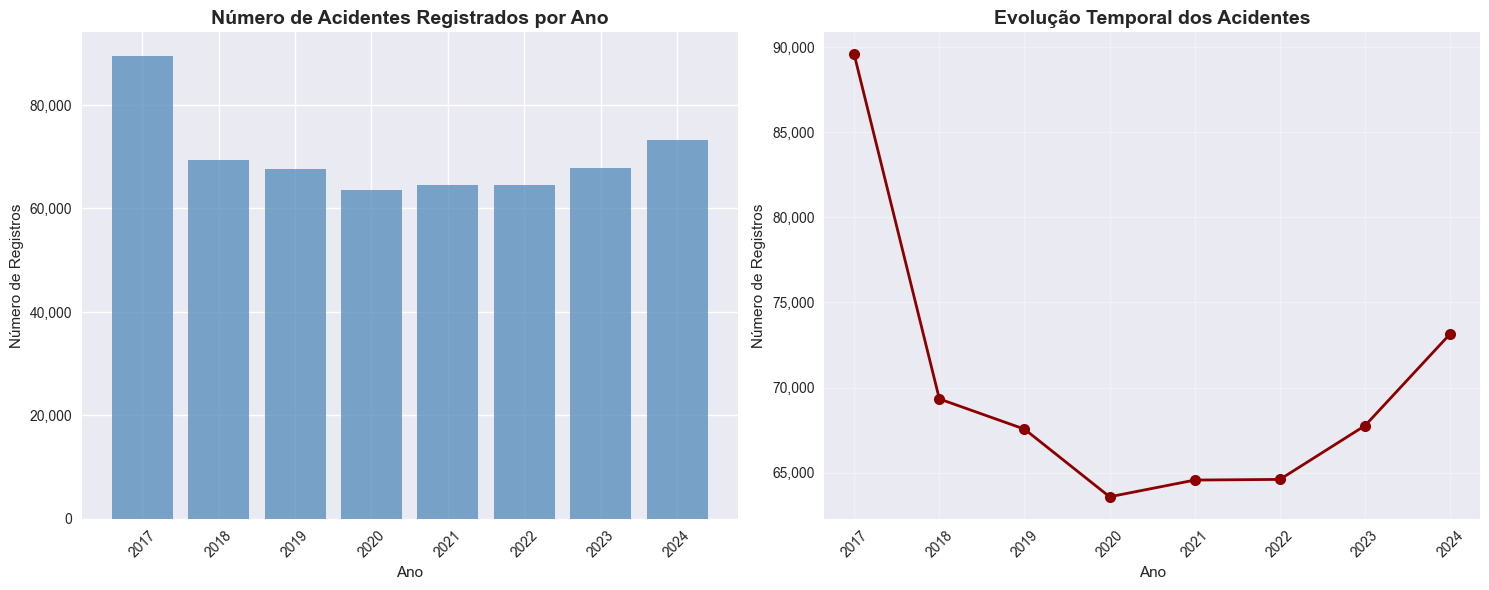

📈 Estatísticas dos Registros por Ano:
  - Total de acidentes (2017-2024): 560,138
  - Média anual: 70017
  - Mediana: 67662
  - Desvio padrão: 8485
  - Ano com mais acidentes: 2017 (89,567)
  - Ano com menos acidentes: 2020 (63,585)


In [5]:
# Visualização: Número de registros por ano
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
ax1.bar(summary_df['Ano'], summary_df['Registros'], color='steelblue', alpha=0.7)
ax1.set_title('Número de Acidentes Registrados por Ano', fontsize=14, fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Número de Registros')
ax1.tick_params(axis='x', rotation=45)

# Formatando números no eixo y
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Gráfico de linha
ax2.plot(summary_df['Ano'], summary_df['Registros'], marker='o', linewidth=2, markersize=8, color='darkred')
ax2.set_title('Evolução Temporal dos Acidentes', fontsize=14, fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Número de Registros')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Formatando números no eixo y
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# Estatísticas descritivas
print("📈 Estatísticas dos Registros por Ano:")
print(f"  - Total de acidentes (2017-2024): {summary_df['Registros'].sum():,}")
print(f"  - Média anual: {summary_df['Registros'].mean():.0f}")
print(f"  - Mediana: {summary_df['Registros'].median():.0f}")
print(f"  - Desvio padrão: {summary_df['Registros'].std():.0f}")
print(f"  - Ano com mais acidentes: {summary_df.loc[summary_df['Registros'].idxmax(), 'Ano']} ({summary_df['Registros'].max():,})")
print(f"  - Ano com menos acidentes: {summary_df.loc[summary_df['Registros'].idxmin(), 'Ano']} ({summary_df['Registros'].min():,})")

## 🔍 Análise das Colunas e Tipos de Dados

In [6]:
# Analisando consistência das colunas entre anos
print("🔍 Análise de Consistência das Colunas:\n")

# Obtendo colunas de cada ano
columns_by_year = {}
for year, df in all_dataframes.items():
    columns_by_year[year] = set(df.columns)

# Encontrando colunas comuns a todos os anos
common_columns = set.intersection(*columns_by_year.values())
print(f"✅ Colunas comuns a todos os anos: {len(common_columns)}")

# Encontrando colunas únicas por ano
all_columns = set.union(*columns_by_year.values())
unique_columns_by_year = {}

for year in columns_by_year:
    unique_cols = columns_by_year[year] - common_columns
    if unique_cols:
        unique_columns_by_year[year] = unique_cols
        print(f"⚠️  {year} tem {len(unique_cols)} colunas únicas: {list(unique_cols)[:3]}{'...' if len(unique_cols) > 3 else ''}")

print(f"\n📊 Total de colunas únicas em toda a base: {len(all_columns)}")

# Mostrando algumas colunas comuns importantes
print("\n🔑 Principais colunas comuns (primeiras 15):")
for i, col in enumerate(sorted(list(common_columns))[:15]):
    print(f"  {i+1:2d}. {col}")

🔍 Análise de Consistência das Colunas:

✅ Colunas comuns a todos os anos: 30

📊 Total de colunas únicas em toda a base: 30

🔑 Principais colunas comuns (primeiras 15):
   1. br
   2. causa_acidente
   3. classificacao_acidente
   4. condicao_metereologica
   5. data_inversa
   6. delegacia
   7. dia_semana
   8. fase_dia
   9. feridos
  10. feridos_graves
  11. feridos_leves
  12. horario
  13. id
  14. ignorados
  15. ilesos


In [7]:
# Analisando tipos de dados e valores únicos em uma amostra
sample_year = '2023'  # Usando 2023 como referência
sample_df = all_dataframes[sample_year]

print(f"🔍 Análise detalhada dos dados de {sample_year}:\n")

# Informações gerais
print(f"📊 Informações Gerais:")
print(f"  - Registros: {len(sample_df):,}")
print(f"  - Colunas: {len(sample_df.columns)}")
print(f"  - Memória utilizada: {sample_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Análise de tipos de dados
dtype_counts = sample_df.dtypes.value_counts()
print(f"\n📋 Distribuição de Tipos de Dados:")
for dtype, count in dtype_counts.items():
    print(f"  - {dtype}: {count} colunas")

# Identificando possíveis colunas categóricas (com poucos valores únicos)
print(f"\n🏷️  Possíveis Variáveis Categóricas (≤ 50 valores únicos):")
categorical_candidates = []
for col in sample_df.columns:
    unique_count = sample_df[col].nunique()
    if unique_count <= 50 and unique_count > 1:
        categorical_candidates.append((col, unique_count))

# Ordenando por número de valores únicos
categorical_candidates.sort(key=lambda x: x[1])

for col, unique_count in categorical_candidates[:10]:  # Mostrando apenas os primeiros 10
    print(f"  - {col}: {unique_count} valores únicos")

if len(categorical_candidates) > 10:
    print(f"  ... e mais {len(categorical_candidates) - 10} colunas")

🔍 Análise detalhada dos dados de 2023:

📊 Informações Gerais:
  - Registros: 67,766
  - Colunas: 30
  - Memória utilizada: 90.9 MB

📋 Distribuição de Tipos de Dados:
  - object: 20 colunas
  - int64: 10 colunas

🏷️  Possíveis Variáveis Categóricas (≤ 50 valores únicos):
  - uso_solo: 2 valores únicos
  - classificacao_acidente: 3 valores únicos
  - sentido_via: 3 valores únicos
  - tipo_pista: 3 valores únicos
  - fase_dia: 4 valores únicos
  - dia_semana: 7 valores únicos
  - mortos: 8 valores únicos
  - condicao_metereologica: 10 valores únicos
  - tipo_acidente: 16 valores únicos
  - feridos_graves: 16 valores únicos
  ... e mais 6 colunas


🔍 Análise de Valores Ausentes (2023):

⚠️  Colunas com valores ausentes: 4

🔝 Top 10 colunas com mais valores ausentes:


,Coluna,Valores_Ausentes,Percentual
29,uop,46,0.067881
28,delegacia,32,0.047221
27,regional,17,0.025086
10,classificacao_acidente,1,0.001476


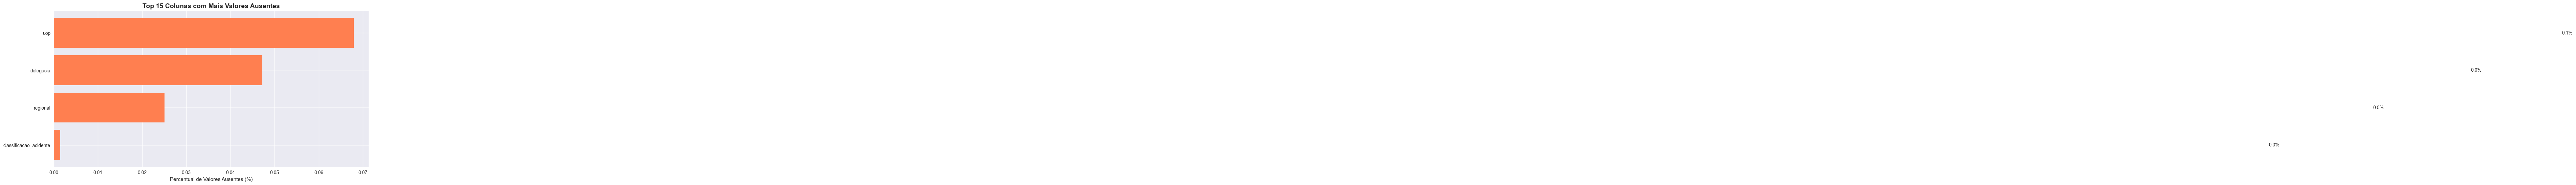

In [8]:
# Analisando valores ausentes
print(f"🔍 Análise de Valores Ausentes ({sample_year}):\n")

missing_data = sample_df.isnull().sum()
missing_percent = (missing_data / len(sample_df)) * 100

# Criando DataFrame com informações de valores ausentes
missing_df = pd.DataFrame({
    'Coluna': missing_data.index,
    'Valores_Ausentes': missing_data.values,
    'Percentual': missing_percent.values
})

# Filtrando apenas colunas com valores ausentes
missing_df = missing_df[missing_df['Valores_Ausentes'] > 0].sort_values('Percentual', ascending=False)

if len(missing_df) > 0:
    print(f"⚠️  Colunas com valores ausentes: {len(missing_df)}")
    print("\n🔝 Top 10 colunas com mais valores ausentes:")
    display(missing_df.head(10))
    
    # Visualização dos valores ausentes
    if len(missing_df) > 0:
        plt.figure(figsize=(12, 6))
        top_missing = missing_df.head(15)
        
        plt.barh(range(len(top_missing)), top_missing['Percentual'], color='coral')
        plt.yticks(range(len(top_missing)), top_missing['Coluna'])
        plt.xlabel('Percentual de Valores Ausentes (%)')
        plt.title('Top 15 Colunas com Mais Valores Ausentes', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        
        # Adicionando valores nas barras
        for i, v in enumerate(top_missing['Percentual']):
            plt.text(v + 0.5, i, f'{v:.1f}%', va='center')
        
        plt.tight_layout()
        plt.show()
else:
    print("✅ Nenhum valor ausente encontrado!")

---

# 3. Data Preparation

## 🧹 Limpeza e Preparação dos Dados

In [9]:
print("🧹 Iniciando processo de limpeza e preparação dos dados...\n")

# Função para padronizar e limpar dados
def clean_datatran_file(df, year):
    """Limpa e padroniza um DataFrame do DATATRAN"""
    print(f"🔧 Processando dados de {year}...")
    
    # Cópia para não modificar o original
    df_clean = df.copy()
    
    # 1. Padronização de nomes de colunas
    df_clean.columns = df_clean.columns.str.strip().str.upper()
    
    # 2. Adicionando coluna de ano
    df_clean['ANO_ACIDENTE'] = int(year)
    
    # 3. Removendo duplicatas
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    duplicates_removed = initial_rows - len(df_clean)
    
    if duplicates_removed > 0:
        print(f"  ✅ Removidas {duplicates_removed} duplicatas")
    
    # 4. Tratamento de colunas de data/hora (se existirem)
    date_columns = [col for col in df_clean.columns if 'DATA' in col or 'HORA' in col]
    
    for col in date_columns:
        if col in df_clean.columns:
            # Tentativa de conversão para datetime
            try:
                if 'DATA' in col:
                    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
                elif 'HORA' in col:
                    df_clean[col] = pd.to_datetime(df_clean[col], format='%H:%M:%S', errors='coerce').dt.time
            except:
                print(f"  ⚠️  Não foi possível converter {col} para datetime")
    
    # 5. Limpeza de strings (removendo espaços extras)
    string_columns = df_clean.select_dtypes(include=['object']).columns
    for col in string_columns:
        if df_clean[col].dtype == 'object':
            df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
            # Substituindo strings vazias por NaN
            df_clean[col] = df_clean[col].replace(['', 'NAN', 'NULL', 'NONE'], np.nan)
    
    print(f"  ✅ Processamento concluído: {len(df_clean):,} registros")
    
    return df_clean

# Aplicando limpeza em todos os arquivos
cleaned_dataframes = {}

for year, df in all_dataframes.items():
    cleaned_df = clean_datatran_file(df, year)
    cleaned_dataframes[year] = cleaned_df

print("\n✅ Limpeza concluída para todos os arquivos!")

🧹 Iniciando processo de limpeza e preparação dos dados...

🔧 Processando dados de 2017...
  ✅ Processamento concluído: 89,567 registros
🔧 Processando dados de 2018...
  ✅ Processamento concluído: 69,333 registros
🔧 Processando dados de 2019...
  ✅ Processamento concluído: 67,558 registros
🔧 Processando dados de 2020...
  ✅ Processamento concluído: 63,585 registros
🔧 Processando dados de 2021...
  ✅ Processamento concluído: 64,567 registros
🔧 Processando dados de 2022...
  ✅ Processamento concluído: 64,606 registros
🔧 Processando dados de 2023...
  ✅ Processamento concluído: 67,766 registros
🔧 Processando dados de 2024...
  ✅ Processamento concluído: 73,156 registros

✅ Limpeza concluída para todos os arquivos!


In [10]:
# Consolidando dados de todos os anos
print("🔗 Consolidando dados de todos os anos...\n")

# Identificando colunas comuns para consolidação
common_cols_clean = set.intersection(*[set(df.columns) for df in cleaned_dataframes.values()])
print(f"📊 Colunas comuns após limpeza: {len(common_cols_clean)}")

# Criando lista de DataFrames apenas com colunas comuns
dfs_to_concat = []
for year, df in cleaned_dataframes.items():
    df_common = df[list(common_cols_clean)].copy()
    dfs_to_concat.append(df_common)
    print(f"  - {year}: {len(df_common):,} registros")

# Consolidando em um único DataFrame
df_consolidated = pd.concat(dfs_to_concat, ignore_index=True)

print(f"\n✅ Consolidação concluída!")
print(f"  - Total de registros: {len(df_consolidated):,}")
print(f"  - Total de colunas: {len(df_consolidated.columns)}")
print(f"  - Período: {df_consolidated['ANO_ACIDENTE'].min()} - {df_consolidated['ANO_ACIDENTE'].max()}")
print(f"  - Tamanho em memória: {df_consolidated.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

🔗 Consolidando dados de todos os anos...

📊 Colunas comuns após limpeza: 31
  - 2017: 89,567 registros
  - 2018: 69,333 registros
  - 2019: 67,558 registros
  - 2020: 63,585 registros
  - 2021: 64,567 registros
  - 2022: 64,606 registros
  - 2023: 67,766 registros
  - 2024: 73,156 registros

✅ Consolidação concluída!
  - Total de registros: 560,138
  - Total de colunas: 31
  - Período: 2017 - 2024
  - Tamanho em memória: 685.5 MB


In [11]:
# Salvando dados consolidados
consolidated_file = os.path.join(processed_data_path, 'datatran_consolidated_2017_2024.csv')

print(f"💾 Salvando dados consolidados em: {consolidated_file}")
df_consolidated.to_csv(consolidated_file, index=False, encoding='utf-8')
print(f"✅ Arquivo salvo com sucesso!")

# Salvando também um arquivo com informações sobre a consolidação
consolidation_info = {
    'data_processamento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_registros': len(df_consolidated),
    'total_colunas': len(df_consolidated.columns),
    'anos_incluidos': sorted(df_consolidated['ANO_ACIDENTE'].unique().tolist()),
    'colunas_comuns': sorted(list(common_cols_clean)),
    'registros_por_ano': df_consolidated['ANO_ACIDENTE'].value_counts().sort_index().to_dict()
}

info_file = os.path.join(processed_data_path, 'consolidation_info.txt')
with open(info_file, 'w', encoding='utf-8') as f:
    f.write("INFORMAÇÕES DA CONSOLIDAÇÃO DOS DADOS DATATRAN\n")
    f.write("=" * 50 + "\n\n")
    for key, value in consolidation_info.items():
        f.write(f"{key.upper()}: {value}\n")

print(f"📄 Informações da consolidação salvas em: {info_file}")

💾 Salvando dados consolidados em: ../data/processed_data/datatran_consolidated_2017_2024.csv
✅ Arquivo salvo com sucesso!
📄 Informações da consolidação salvas em: ../data/processed_data/consolidation_info.txt


## 📊 Visualização: Antes vs Depois da Limpeza

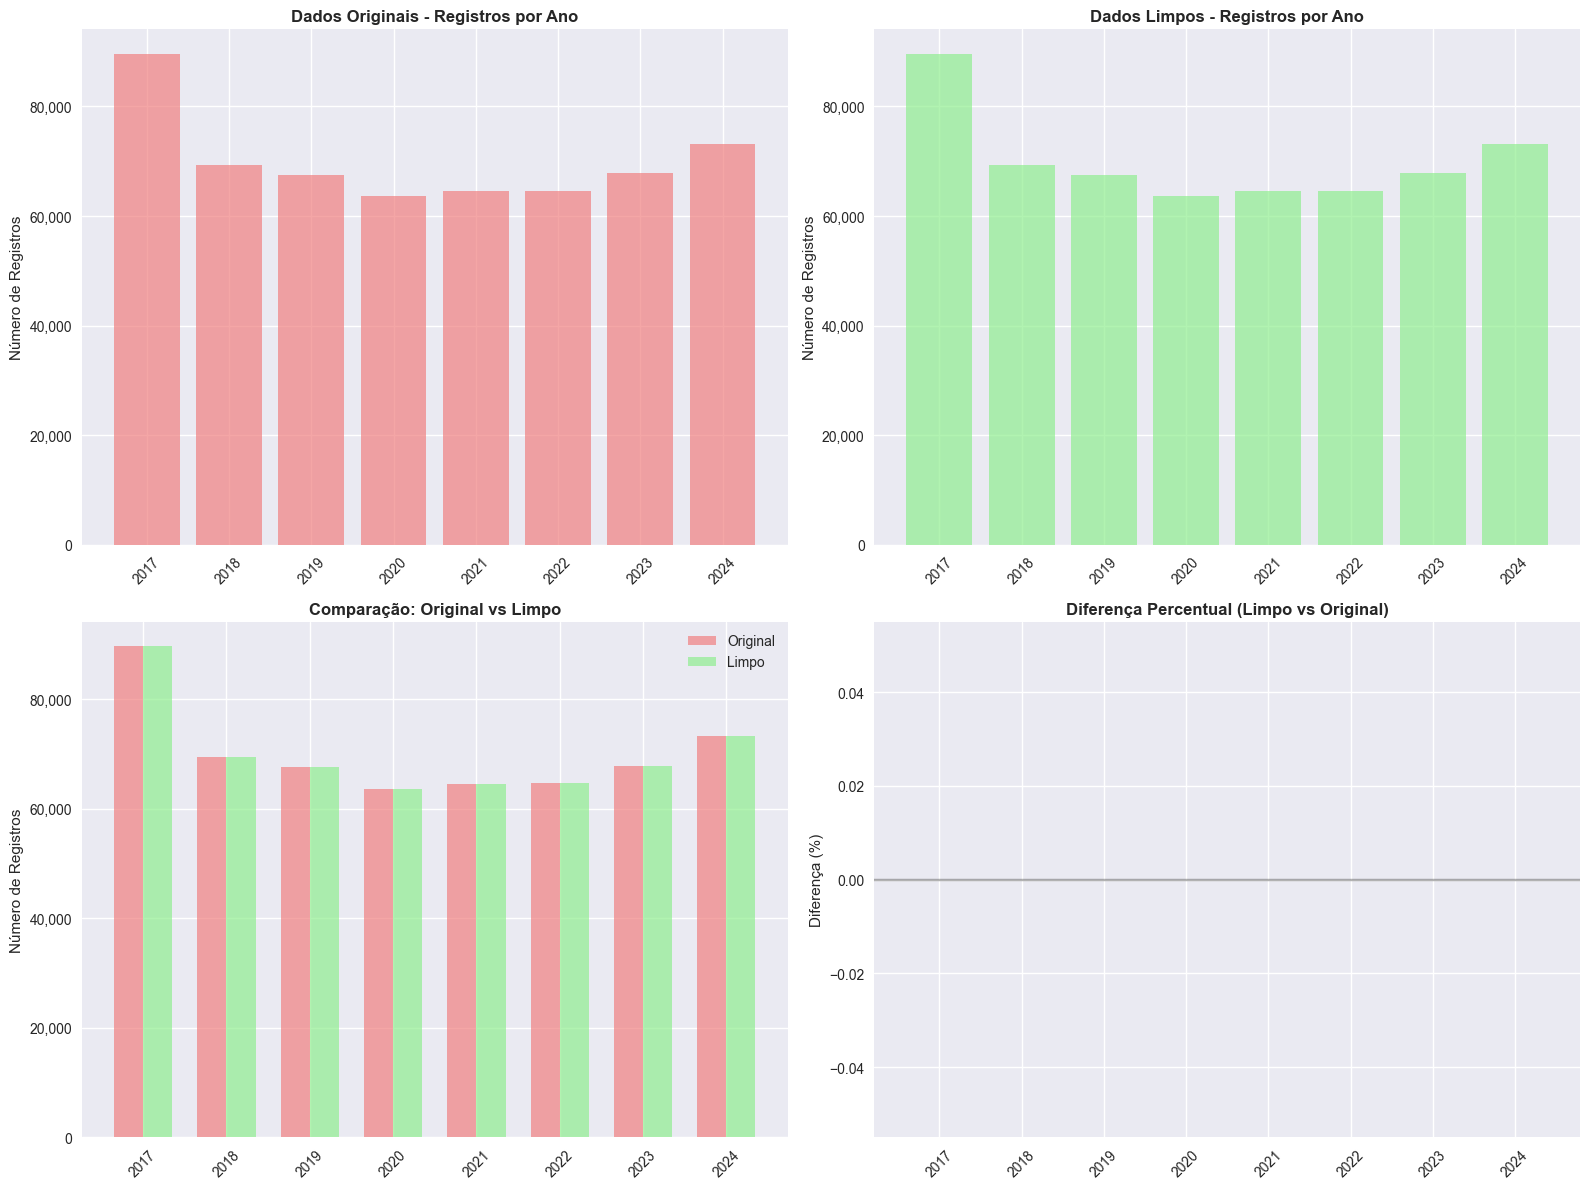

📊 Resumo da Limpeza:
  - Registros originais: 560,138
  - Registros após limpeza: 560,138
  - Diferença: 0 (+0.00%)
  - Colunas consolidadas: 31


In [12]:
# Comparação antes e depois da limpeza
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Número de registros por ano (antes)
original_counts = [len(all_dataframes[year]) for year in sorted(all_dataframes.keys())]
years = sorted(all_dataframes.keys())

ax1.bar(years, original_counts, color='lightcoral', alpha=0.7, label='Dados Originais')
ax1.set_title('Dados Originais - Registros por Ano', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Registros')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# 2. Número de registros por ano (depois)
cleaned_counts = df_consolidated['ANO_ACIDENTE'].value_counts().sort_index()

ax2.bar(cleaned_counts.index.astype(str), cleaned_counts.values, color='lightgreen', alpha=0.7, label='Dados Limpos')
ax2.set_title('Dados Limpos - Registros por Ano', fontsize=12, fontweight='bold')
ax2.set_ylabel('Número de Registros')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# 3. Comparação direta
comparison_data = pd.DataFrame({
    'Ano': years,
    'Original': original_counts,
    'Limpo': [cleaned_counts[int(year)] for year in years]
})

x = np.arange(len(years))
width = 0.35

ax3.bar(x - width/2, comparison_data['Original'], width, label='Original', color='lightcoral', alpha=0.7)
ax3.bar(x + width/2, comparison_data['Limpo'], width, label='Limpo', color='lightgreen', alpha=0.7)
ax3.set_title('Comparação: Original vs Limpo', fontsize=12, fontweight='bold')
ax3.set_ylabel('Número de Registros')
ax3.set_xticks(x)
ax3.set_xticklabels(years, rotation=45)
ax3.legend()
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# 4. Diferença percentual
comparison_data['Diferenca_Pct'] = ((comparison_data['Limpo'] - comparison_data['Original']) / comparison_data['Original']) * 100

colors = ['red' if x < 0 else 'green' for x in comparison_data['Diferenca_Pct']]
ax4.bar(comparison_data['Ano'], comparison_data['Diferenca_Pct'], color=colors, alpha=0.7)
ax4.set_title('Diferença Percentual (Limpo vs Original)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Diferença (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas da limpeza
total_original = sum(original_counts)
total_limpo = len(df_consolidated)
diferenca = total_limpo - total_original
diferenca_pct = (diferenca / total_original) * 100

print(f"📊 Resumo da Limpeza:")
print(f"  - Registros originais: {total_original:,}")
print(f"  - Registros após limpeza: {total_limpo:,}")
print(f"  - Diferença: {diferenca:,} ({diferenca_pct:+.2f}%)")
print(f"  - Colunas consolidadas: {len(common_cols_clean)}")

---

# 4. Análise Exploratória de Dados (AED)

## 📈 Estatísticas Descritivas e Análises Iniciais

In [13]:
print("📊 Iniciando Análise Exploratória de Dados (AED)...\n")

# Informações gerais do dataset consolidado
print("🔍 Informações Gerais do Dataset:")
print(f"  - Período analisado: {df_consolidated['ANO_ACIDENTE'].min()} - {df_consolidated['ANO_ACIDENTE'].max()}")
print(f"  - Total de acidentes: {len(df_consolidated):,}")
print(f"  - Média anual: {len(df_consolidated) / df_consolidated['ANO_ACIDENTE'].nunique():.0f} acidentes")
print(f"  - Variáveis disponíveis: {len(df_consolidated.columns)}")

# Distribuição por ano
yearly_stats = df_consolidated['ANO_ACIDENTE'].value_counts().sort_index()
print(f"\n📅 Distribuição Anual:")
for year, count in yearly_stats.items():
    pct = (count / len(df_consolidated)) * 100
    print(f"  - {year}: {count:,} acidentes ({pct:.1f}%)")

# Estatísticas descritivas básicas
print(f"\n📊 Estatísticas da Distribuição Anual:")
print(f"  - Média: {yearly_stats.mean():.0f}")
print(f"  - Mediana: {yearly_stats.median():.0f}")
print(f"  - Desvio Padrão: {yearly_stats.std():.0f}")
print(f"  - Coeficiente de Variação: {(yearly_stats.std() / yearly_stats.mean()) * 100:.1f}%")
print(f"  - Amplitude: {yearly_stats.max() - yearly_stats.min():,}")

📊 Iniciando Análise Exploratória de Dados (AED)...

🔍 Informações Gerais do Dataset:
  - Período analisado: 2017 - 2024
  - Total de acidentes: 560,138
  - Média anual: 70017 acidentes
  - Variáveis disponíveis: 31

📅 Distribuição Anual:
  - 2017: 89,567 acidentes (16.0%)
  - 2018: 69,333 acidentes (12.4%)
  - 2019: 67,558 acidentes (12.1%)
  - 2020: 63,585 acidentes (11.4%)
  - 2021: 64,567 acidentes (11.5%)
  - 2022: 64,606 acidentes (11.5%)
  - 2023: 67,766 acidentes (12.1%)
  - 2024: 73,156 acidentes (13.1%)

📊 Estatísticas da Distribuição Anual:
  - Média: 70017
  - Mediana: 67662
  - Desvio Padrão: 8485
  - Coeficiente de Variação: 12.1%
  - Amplitude: 25,982


🔢 Variáveis Numéricas Identificadas: 10

📊 Estatísticas Descritivas das Variáveis Numéricas:


,VEICULOS,IGNORADOS,FERIDOS_GRAVES,ILESOS,FERIDOS,FERIDOS_LEVES,ID,MORTOS,PESSOAS,BR
count,560138.00,560138.00,560138.00,560138.00,560138.00,560138.00,560138.00,560138.00,560138.00,560138.00
mean,1.96,0.37,0.26,1.04,1.11,0.84,326860.99,0.08,2.53,212.33
std,1.09,0.80,0.61,1.55,1.22,1.09,191092.48,0.34,2.02,130.65
min,1.00,0.00,0.00,0.00,0.00,0.00,8.00,0.00,1.00,0.00
25%,1.00,0.00,0.00,0.00,1.00,0.00,162113.25,0.00,2.00,101.00
50%,2.00,0.00,0.00,1.00,1.00,1.00,321920.50,0.00,2.00,163.00
75%,2.00,1.00,0.00,1.00,1.00,1.00,499143.75,0.00,3.00,324.00
max,131.00,88.00,35.00,78.00,84.00,83.00,661607.00,37.00,95.00,498.00


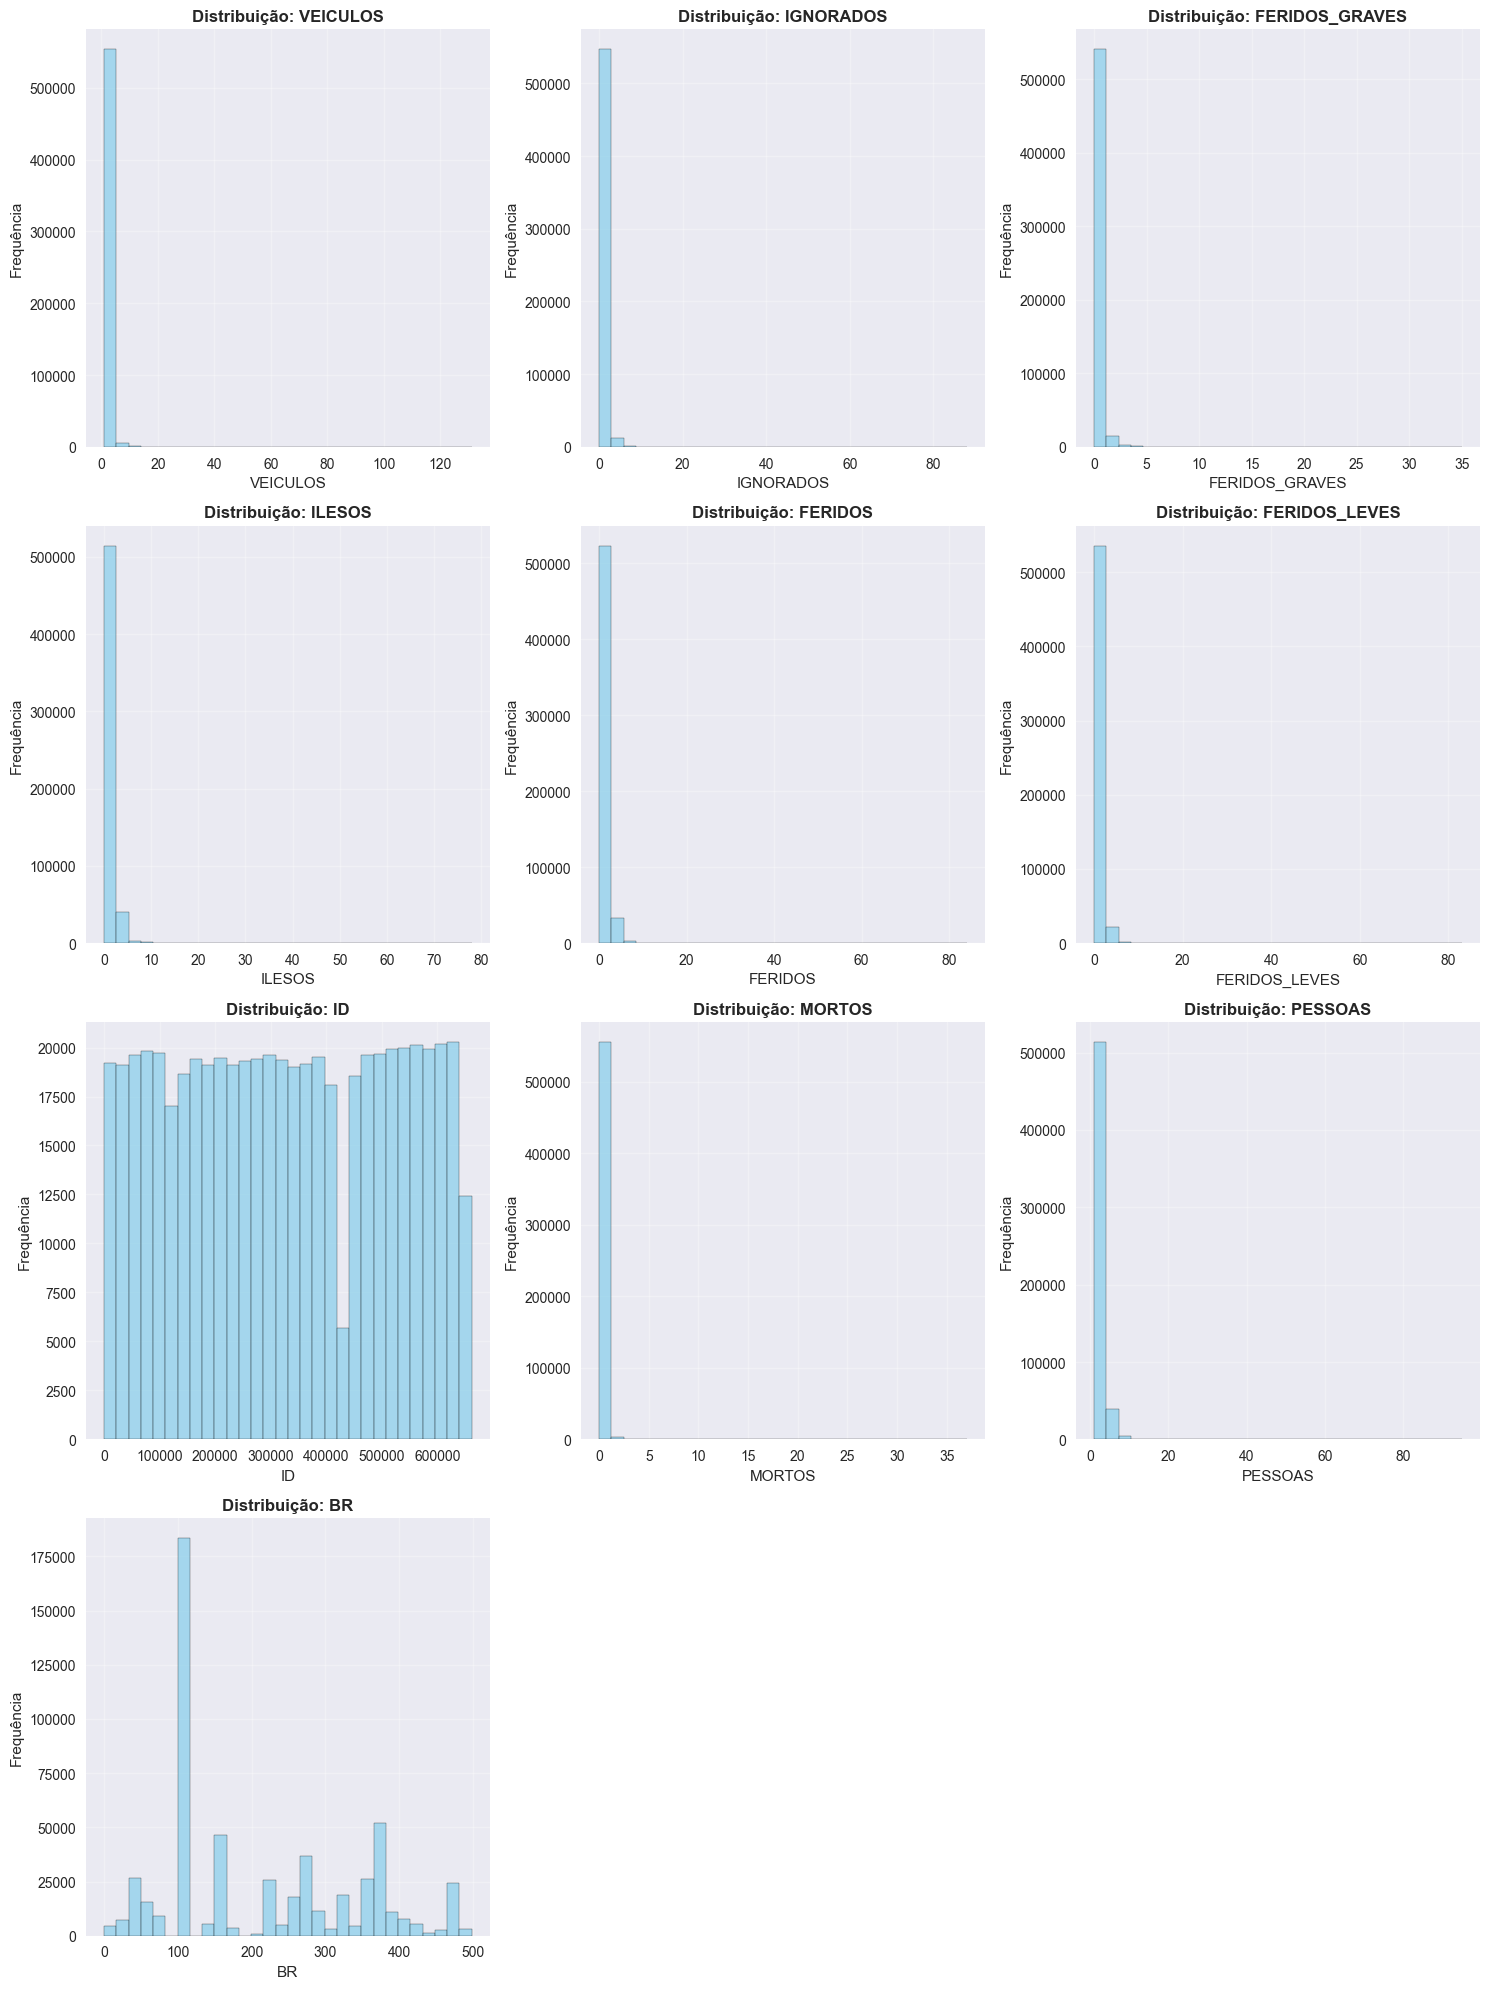

In [14]:
# Análise de variáveis numéricas
numeric_columns = df_consolidated.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col != 'ANO_ACIDENTE']  # Removendo ano

print(f"🔢 Variáveis Numéricas Identificadas: {len(numeric_columns)}")

if len(numeric_columns) > 0:
    print("\n📊 Estatísticas Descritivas das Variáveis Numéricas:")
    
    # Selecionando algumas variáveis numéricas importantes para análise
    important_numeric = [col for col in numeric_columns[:10]]  # Primeiras 10 para não sobrecarregar
    
    if important_numeric:
        desc_stats = df_consolidated[important_numeric].describe()
        display(desc_stats.round(2))
        
        # Visualização das distribuições
        n_cols = min(3, len(important_numeric))
        n_rows = (len(important_numeric) + n_cols - 1) // n_cols
        
        if len(important_numeric) > 0:
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
            if n_rows == 1:
                axes = [axes] if n_cols == 1 else axes
            else:
                axes = axes.flatten()
            
            for i, col in enumerate(important_numeric[:n_rows*n_cols]):
                if i < len(axes):
                    # Removendo valores nulos para o histograma
                    data = df_consolidated[col].dropna()
                    
                    if len(data) > 0:
                        axes[i].hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
                        axes[i].set_title(f'Distribuição: {col}', fontweight='bold')
                        axes[i].set_xlabel(col)
                        axes[i].set_ylabel('Frequência')
                        axes[i].grid(True, alpha=0.3)
                    else:
                        axes[i].text(0.5, 0.5, 'Sem dados\ndisponíveis', 
                                   ha='center', va='center', transform=axes[i].transAxes)
                        axes[i].set_title(f'{col} - Sem Dados')
            
            # Removendo subplots vazios
            for i in range(len(important_numeric), len(axes)):
                fig.delaxes(axes[i])
            
            plt.tight_layout()
            plt.show()
else:
    print("⚠️  Nenhuma variável numérica encontrada além do ano.")

🏷️  Variáveis Categóricas Identificadas: 19

📊 Análise das Principais Variáveis Categóricas:

🔍 Resumo das Variáveis Categóricas:


,Variavel,Valores_Unicos,Valores_Nulos,Pct_Nulos
17,USO_SOLO,2,0,0.000000
1,CLASSIFICACAO_ACIDENTE,3,9,0.001607
15,TIPO_PISTA,3,0,0.000000
2,SENTIDO_VIA,3,0,0.000000
4,FASE_DIA,4,0,0.000000
18,DIA_SEMANA,7,0,0.000000
12,CONDICAO_METEREOLOGICA,10,0,0.000000
11,TIPO_ACIDENTE,21,41,0.007320
8,UF,27,0,0.000000
13,REGIONAL,28,27,0.004820



📈 Variáveis adequadas para visualização: 7


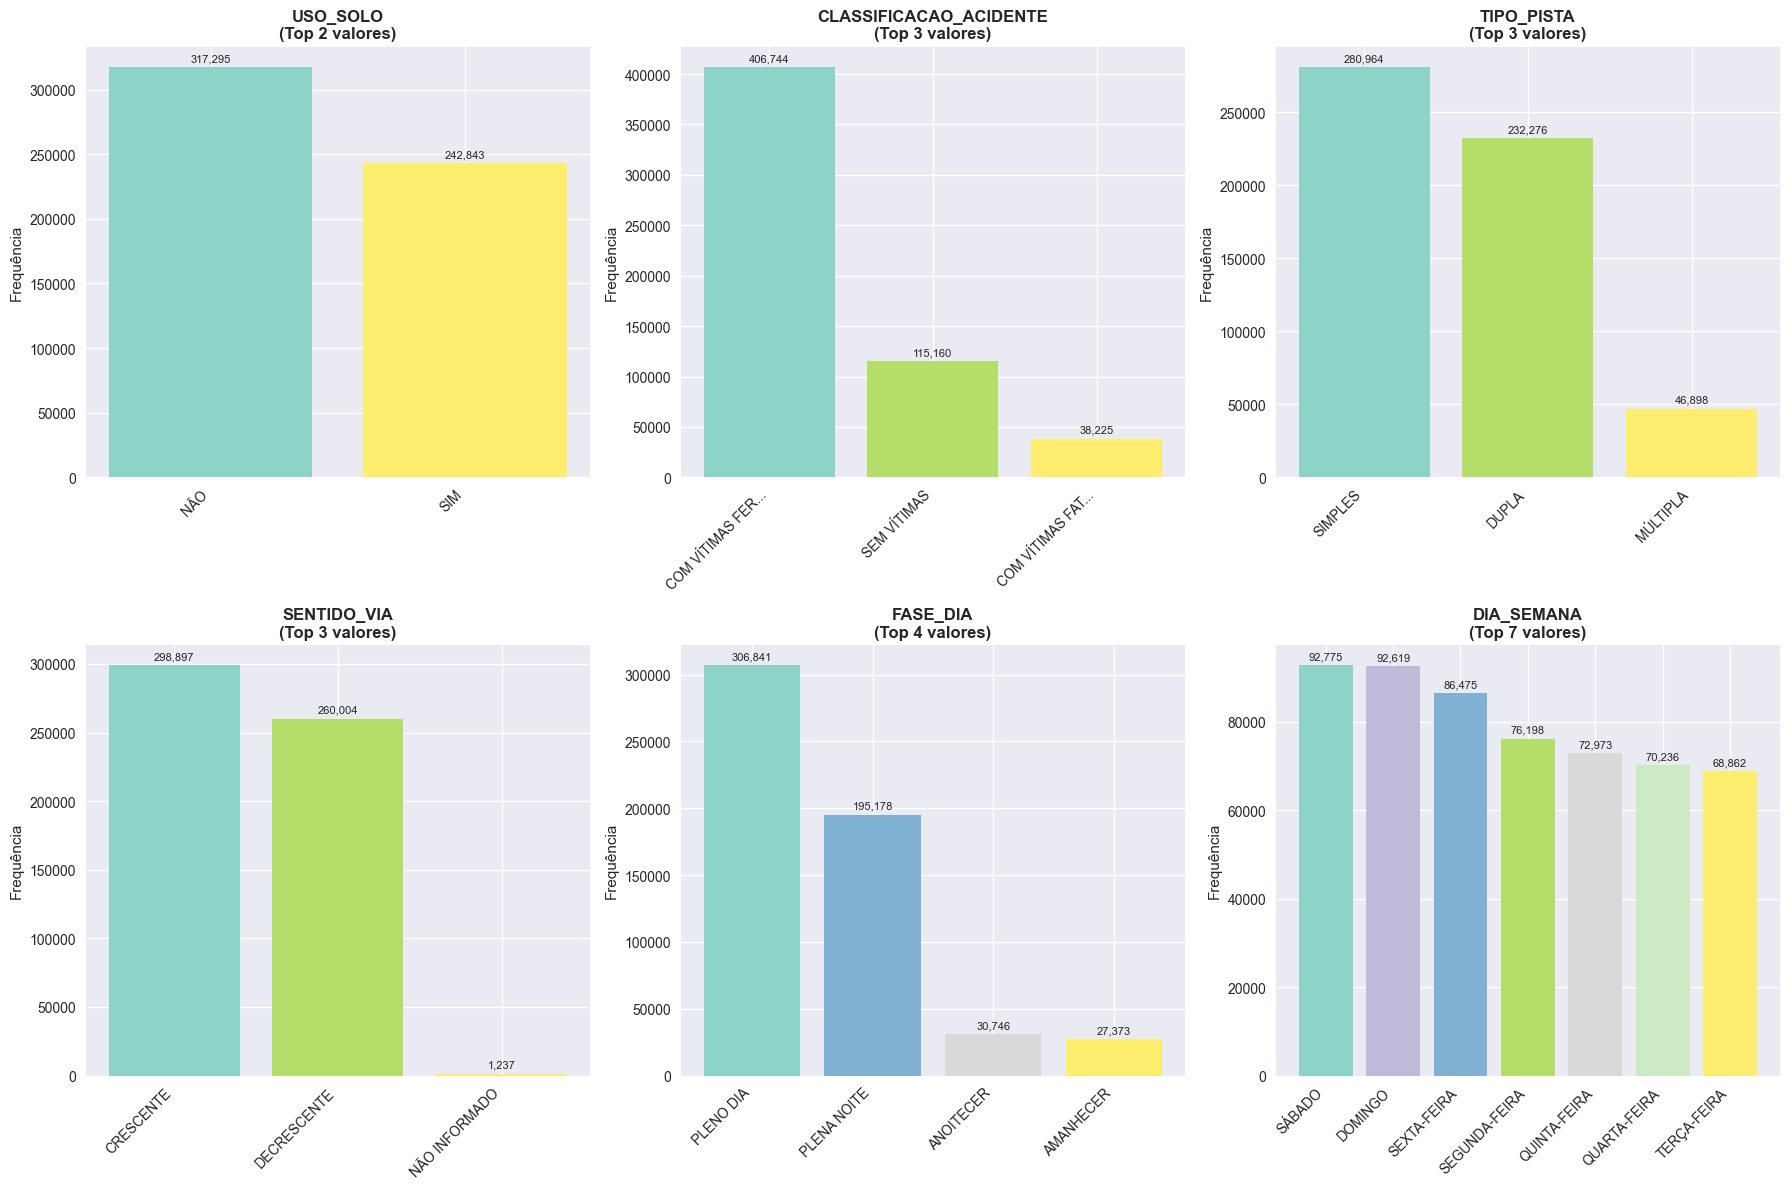

In [15]:
# Análise de variáveis categóricas
categorical_columns = df_consolidated.select_dtypes(include=['object']).columns.tolist()

print(f"🏷️  Variáveis Categóricas Identificadas: {len(categorical_columns)}")

if len(categorical_columns) > 0:
    print("\n📊 Análise das Principais Variáveis Categóricas:")
    
    # Analisando cardinalidade das variáveis categóricas
    categorical_info = []
    for col in categorical_columns:
        unique_count = df_consolidated[col].nunique()
        null_count = df_consolidated[col].isnull().sum()
        null_pct = (null_count / len(df_consolidated)) * 100
        
        categorical_info.append({
            'Variavel': col,
            'Valores_Unicos': unique_count,
            'Valores_Nulos': null_count,
            'Pct_Nulos': null_pct
        })
    
    cat_df = pd.DataFrame(categorical_info).sort_values('Valores_Unicos')
    
    print("\n🔍 Resumo das Variáveis Categóricas:")
    display(cat_df.head(15))  # Mostrando as 15 primeiras
    
    # Selecionando variáveis categóricas com cardinalidade adequada para visualização
    suitable_categorical = cat_df[(cat_df['Valores_Unicos'] >= 2) & 
                                 (cat_df['Valores_Unicos'] <= 20) & 
                                 (cat_df['Pct_Nulos'] < 50)]['Variavel'].tolist()
    
    print(f"\n📈 Variáveis adequadas para visualização: {len(suitable_categorical)}")
    
    # Visualizando algumas variáveis categóricas importantes
    if len(suitable_categorical) > 0:
        n_vars_to_plot = min(6, len(suitable_categorical))
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for i, col in enumerate(suitable_categorical[:n_vars_to_plot]):
            # Contagem de valores
            value_counts = df_consolidated[col].value_counts().head(10)  # Top 10 valores
            
            # Gráfico de barras
            axes[i].bar(range(len(value_counts)), value_counts.values, 
                       color=plt.cm.Set3(np.linspace(0, 1, len(value_counts))))
            axes[i].set_title(f'{col}\n(Top {len(value_counts)} valores)', fontweight='bold')
            axes[i].set_xticks(range(len(value_counts)))
            axes[i].set_xticklabels([str(x)[:15] + '...' if len(str(x)) > 15 else str(x) 
                                   for x in value_counts.index], rotation=45, ha='right')
            axes[i].set_ylabel('Frequência')
            
            # Adicionando valores nas barras
            for j, v in enumerate(value_counts.values):
                axes[i].text(j, v + max(value_counts.values) * 0.01, f'{v:,}', 
                           ha='center', va='bottom', fontsize=8)
        
        # Removendo subplots vazios
        for i in range(n_vars_to_plot, len(axes)):
            fig.delaxes(axes[i])
        
        plt.tight_layout()
        plt.show()
else:
    print("⚠️  Nenhuma variável categórica encontrada.")

## 📊 Análise Temporal Detalhada

⏰ Análise Temporal dos Acidentes:

📈 Evolução Anual e Variação:
  - 2017: 89,567 acidentes (baseline)
  - 2018: 69,333 acidentes 📉 (-22.6%)
  - 2019: 67,558 acidentes 📉 (-2.6%)
  - 2020: 63,585 acidentes 📉 (-5.9%)
  - 2021: 64,567 acidentes 📈 (+1.5%)
  - 2022: 64,606 acidentes 📈 (+0.1%)
  - 2023: 67,766 acidentes 📈 (+4.9%)
  - 2024: 73,156 acidentes 📈 (+8.0%)


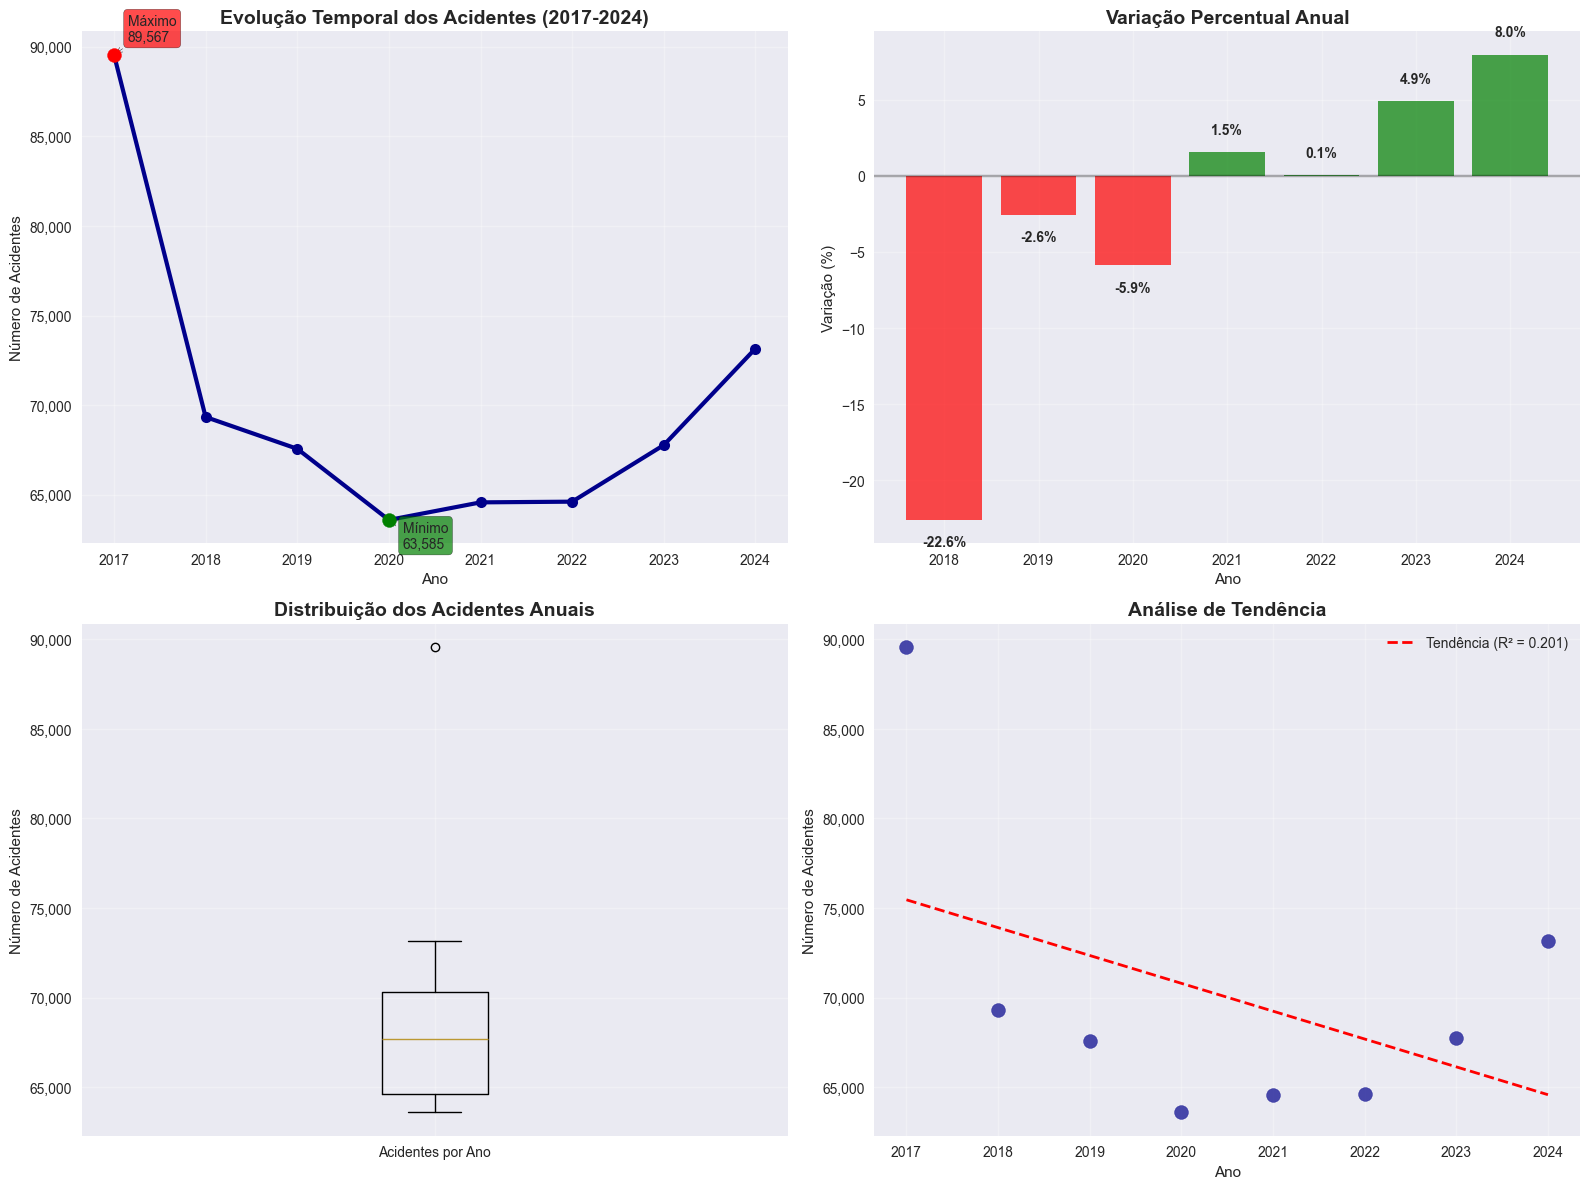


📊 Análise de Tendência:
  - Coeficiente angular: -1555 acidentes/ano
  - R² (coeficiente de determinação): 0.201
  - P-valor: 0.2647
  - ⚠️  Tendência não é estatisticamente significativa

📈 Estatísticas Temporais:
  - Período de maior crescimento: 2024 (8.0%)
  - Período de maior redução: 2018 (-22.6%)
  - Volatilidade (desvio padrão das variações): 10.0%


In [16]:
# Análise temporal detalhada
print("⏰ Análise Temporal dos Acidentes:\n")

# Evolução anual
yearly_evolution = df_consolidated['ANO_ACIDENTE'].value_counts().sort_index()

# Calculando variação ano a ano
yearly_change = yearly_evolution.pct_change() * 100

print("📈 Evolução Anual e Variação:")
for year in yearly_evolution.index:
    count = yearly_evolution[year]
    if year in yearly_change.index and not pd.isna(yearly_change[year]):
        change = yearly_change[year]
        change_symbol = "📈" if change > 0 else "📉" if change < 0 else "➡️"
        print(f"  - {year}: {count:,} acidentes {change_symbol} ({change:+.1f}%)")
    else:
        print(f"  - {year}: {count:,} acidentes (baseline)")

# Visualização da evolução temporal
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Evolução anual - Linha
ax1.plot(yearly_evolution.index, yearly_evolution.values, marker='o', linewidth=3, markersize=8, color='darkblue')
ax1.set_title('Evolução Temporal dos Acidentes (2017-2024)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Número de Acidentes')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Destacando pontos máximo e mínimo
max_year = yearly_evolution.idxmax()
min_year = yearly_evolution.idxmin()
ax1.scatter([max_year], [yearly_evolution[max_year]], color='red', s=100, zorder=5)
ax1.scatter([min_year], [yearly_evolution[min_year]], color='green', s=100, zorder=5)
ax1.annotate(f'Máximo\n{yearly_evolution[max_year]:,}', 
            xy=(max_year, yearly_evolution[max_year]), 
            xytext=(10, 10), textcoords='offset points', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
ax1.annotate(f'Mínimo\n{yearly_evolution[min_year]:,}', 
            xy=(min_year, yearly_evolution[min_year]), 
            xytext=(10, -20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# 2. Variação percentual ano a ano
yearly_change_clean = yearly_change.dropna()
colors = ['red' if x < 0 else 'green' for x in yearly_change_clean.values]
ax2.bar(yearly_change_clean.index, yearly_change_clean.values, color=colors, alpha=0.7)
ax2.set_title('Variação Percentual Anual', fontsize=14, fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Variação (%)')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(True, alpha=0.3)

# Adicionando valores nas barras
for i, (year, value) in enumerate(yearly_change_clean.items()):
    ax2.text(year, value + (1 if value > 0 else -1), f'{value:.1f}%', 
            ha='center', va='bottom' if value > 0 else 'top', fontweight='bold')

# 3. Boxplot da distribuição anual
ax3.boxplot([yearly_evolution.values], labels=['Acidentes por Ano'])
ax3.set_title('Distribuição dos Acidentes Anuais', fontsize=14, fontweight='bold')
ax3.set_ylabel('Número de Acidentes')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax3.grid(True, alpha=0.3)

# 4. Tendência com linha de regressão
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(yearly_evolution.index, yearly_evolution.values)

ax4.scatter(yearly_evolution.index, yearly_evolution.values, color='darkblue', s=100, alpha=0.7)
ax4.plot(yearly_evolution.index, slope * yearly_evolution.index + intercept, 
         color='red', linewidth=2, linestyle='--', label=f'Tendência (R² = {r_value**2:.3f})')
ax4.set_title('Análise de Tendência', fontsize=14, fontweight='bold')
ax4.set_xlabel('Ano')
ax4.set_ylabel('Número de Acidentes')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# Interpretação da tendência
print(f"\n📊 Análise de Tendência:")
print(f"  - Coeficiente angular: {slope:.0f} acidentes/ano")
print(f"  - R² (coeficiente de determinação): {r_value**2:.3f}")
print(f"  - P-valor: {p_value:.4f}")

if p_value < 0.05:
    trend_direction = "crescente" if slope > 0 else "decrescente"
    print(f"  - ✅ Tendência {trend_direction} estatisticamente significativa")
else:
    print(f"  - ⚠️  Tendência não é estatisticamente significativa")

# Estatísticas adicionais
print(f"\n📈 Estatísticas Temporais:")
print(f"  - Período de maior crescimento: {yearly_change.idxmax()} ({yearly_change.max():.1f}%)")
print(f"  - Período de maior redução: {yearly_change.idxmin()} ({yearly_change.min():.1f}%)")
print(f"  - Volatilidade (desvio padrão das variações): {yearly_change.std():.1f}%")

## 🎯 Próximos Passos

### ✅ Etapas Concluídas:
1. **Business Understanding** - Contexto do DATATRAN e problemas de negócio identificados
2. **Data Understanding** - Exploração inicial dos dados (2017-2024)
3. **Data Preparation** - Limpeza, padronização e consolidação dos dados
4. **AED Inicial** - Análises temporais e estatísticas descritivas básicas

### 🔄 Próximas Análises a Implementar:
1. **Análise de Correlações** - Matriz de correlação e identificação de relações
2. **Análise Geográfica** - Distribuição por estados e rodovias
3. **Análise de Causas** - Principais fatores contribuintes
4. **Análise de Sazonalidade** - Padrões por mês, dia da semana, horário
5. **Análise de Gravidade** - Relação entre fatores e severidade dos acidentes
6. **Detecção de Outliers** - Identificação de padrões anômalos
7. **Análise de Impacto da Pandemia** - Comparação 2019 vs 2020-2021

### 📊 Visualizações Pendentes:
- Heatmaps de correlação
- Mapas geográficos
- Análises de séries temporais detalhadas
- Gráficos de dispersão para relações não-lineares
- Dashboards interativos

---

*Este notebook será continuamente atualizado com novas análises e insights conforme o projeto avança.*